# Business Insights and Model Interpretation

This notebook focuses on interpreting the predictions of the final customer churn model and translating them into actionable business insights. While the previous notebooks concentrated on data preparation, feature engineering, model development, and evaluation, this notebook bridges the gap between machine learning outputs and business decision-making.

The objective is to identify the key factors influencing customer churn, segment customers based on their churn risk, and recommend practical retention strategies that can help reduce customer attrition. In addition, this notebook evaluates the potential business value of deploying the predictive model through customer segmentation and cost-benefit analysis.

By the end of this notebook, the machine learning model will not only provide accurate churn predictions but also support data-driven business decisions aimed at improving customer retention and maximizing organizational value.

## Objectives

The objectives of this notebook are to:

- Interpret the predictions generated by the final machine learning model.
- Identify the most important features influencing customer churn.
- Measure feature importance using both model-based and permutation-based techniques.
- Segment customers into different churn risk categories based on predicted probabilities.
- Develop actionable customer retention strategies for each risk segment.
- Perform a simple business cost-benefit analysis to estimate the potential value of implementing the churn prediction model.
- Summarize key business insights and recommendations for stakeholders.

# Import Libraries

The following libraries are imported to perform model interpretation, feature importance analysis, visualization, customer segmentation, and business analysis.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Model persistence
import joblib

# Model interpretation
from sklearn.inspection import permutation_importance

# Evaluation
from sklearn.metrics import confusion_matrix

# 3. Load the Final Model and Supporting Components

The preprocessing pipeline ensures that new customer data undergoes the same transformations applied during model training, maintaining consistency between training and inference. The optimized threshold is then used to classify customers as either likely to churn or remain with the company based on their predicted churn probability.

Loading these components allows the trained model to make reliable predictions on completely new customer records.

In [2]:
# Load cleaned dataset
df = pd.read_csv("../data/cleaned/churn_clean.csv")

# Load processed test dataset
X_test_processed = joblib.load("../data/processed/X_test_processed.pkl")

# Load test labels
y_test = joblib.load("../data/processed/y_test.pkl")

# Load final trained model
final_model = joblib.load("../models/final_churn_model.pkl")




# Load the final trained XGBoost model
final_model = joblib.load("../models/final_churn_model.pkl")

# Load the preprocessing pipeline
preprocessor = joblib.load("../models/preprocessor.pkl")

# Load the optimized probability threshold
final_threshold = joblib.load("../models/final_threshold.pkl")

In [3]:
# Verify Successfully Loaded Objects

# Display the loaded model
print("Final Model:")
print(final_model)

print("\n" + "="*80)

# Display the preprocessing pipeline
print("Preprocessor:")
print(preprocessor)

print("\n" + "="*80)

# Display the optimized threshold
print(f"Optimized Threshold: {final_threshold:.3f}")

Final Model:
Pipeline(steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=1.0, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=0.5, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               m

### Interpretation

All required components for customer churn prediction have been successfully loaded.

- **Final Model:** Responsible for estimating the probability that a customer will churn.
- **Preprocessing Pipeline:** Ensures that new customer information is transformed using exactly the same feature engineering and encoding steps applied during model training.
- **Optimized Threshold:** Converts predicted churn probabilities into final business decisions by balancing the trade-off between identifying potential churners and minimizing false alarms.

With these components loaded, the system is now ready to evaluate completely new customers and support data-driven customer retention strategies.

# 4. Create New Customer Dataset

To demonstrate how the trained churn prediction model can be used in a real-world business setting, we create a dataset containing information for new customers who have not previously been seen by the model.

The simulated customers closely resemble the original Telco customer dataset and include a variety of customer profiles, such as long-term loyal customers, recently acquired customers, customers on different contract plans, and customers subscribed to different internet and support services.

Using realistic customer records allows us to evaluate how the model performs in practical business scenarios and provides meaningful predictions that can support customer retention strategies.

In [4]:
# Create a simulated dataset of new customers
new_customers = pd.DataFrame({

    "gender": [
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male"
    ],

    "SeniorCitizen": [
        0, 1, 0, 0, 1,
        0, 0, 1, 0, 1
    ],

    "Partner": [
        "Yes", "No", "Yes", "No", "No",
        "Yes", "No", "Yes", "Yes", "No"
    ],

    "Dependents": [
        "Yes", "No", "No", "No", "Yes",
        "Yes", "No", "No", "Yes", "No"
    ],

    "tenure": [
        72, 5, 24, 2, 48,
        60, 12, 8, 36, 1
    ],

    "PhoneService": [
        "Yes", "Yes", "Yes", "No", "Yes",
        "Yes", "Yes", "Yes", "Yes", "No"
    ],

    "MultipleLines": [
        "No", "Yes", "No", "No phone service", "Yes",
        "Yes", "No", "Yes", "No", "No phone service"
    ],

    "InternetService": [
        "Fiber optic", "Fiber optic", "DSL", "Fiber optic", "DSL",
        "DSL", "Fiber optic", "Fiber optic", "DSL", "Fiber optic"
    ],

    "OnlineSecurity": [
        "Yes", "No", "Yes", "No", "Yes",
        "Yes", "No", "No", "Yes", "No"
    ],

    "OnlineBackup": [
        "Yes", "No", "Yes", "No", "No",
        "Yes", "Yes", "No", "Yes", "No"
    ],

    "DeviceProtection": [
        "Yes", "No", "Yes", "No", "Yes",
        "Yes", "No", "No", "Yes", "No"
    ],

    "TechSupport": [
        "Yes", "No", "Yes", "No", "Yes",
        "Yes", "No", "No", "Yes", "No"
    ],

    "StreamingTV": [
        "No", "Yes", "No", "Yes", "Yes",
        "No", "Yes", "Yes", "No", "Yes"
    ],

    "StreamingMovies": [
        "No", "Yes", "Yes", "Yes", "No",
        "No", "Yes", "Yes", "No", "Yes"
    ],

    "Contract": [
        "Two year", "Month-to-month", "One year", "Month-to-month", "One year",
        "Two year", "Month-to-month", "Month-to-month", "One year", "Month-to-month"
    ],

    "PaperlessBilling": [
        "No", "Yes", "Yes", "Yes", "No",
        "No", "Yes", "Yes", "No", "Yes"
    ],

    "PaymentMethod": [
        "Bank transfer (automatic)",
        "Electronic check",
        "Credit card (automatic)",
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Electronic check",
        "Electronic check",
        "Credit card (automatic)",
        "Electronic check"
    ],

    "MonthlyCharges": [
        29.85, 95.50, 70.35, 99.40, 65.25,
        45.10, 89.75, 101.20, 60.50, 105.80
    ],

    "TotalCharges": [
        2152.20, 477.50, 1688.40, 198.80, 3132.00,
        2706.00, 1077.00, 809.60, 2178.00, 105.80
    ],

    "TenureGroup": [
        "61-72 Months",
        "0-12 Months",
        "13-24 Months",
        "0-12 Months",
        "37-48 Months",
        "49-60 Months",
        "0-12 Months",
        "0-12 Months",
        "25-36 Months",
        "0-12 Months"
    ]
})

# Display the simulated customer data
new_customers.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup
0,Female,0,Yes,Yes,72,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),29.85,2152.2,61-72 Months
1,Male,1,No,No,5,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.50,477.5,0-12 Months
2,Female,0,Yes,No,24,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),70.35,1688.4,13-24 Months
3,Male,0,No,No,2,No,No phone service,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.40,198.8,0-12 Months
4,Female,1,No,Yes,48,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,No,One year,No,Mailed check,65.25,3132.0,37-48 Months


## Feature Engineering for New Customer Data

In [5]:
# Create ContractMonths

contract_map = {
    "Month-to-month": 1,
    "One year": 12,
    "Two year": 24
}


new_customers["ContractMonths"] = (
    new_customers["Contract"]
    .map(contract_map)
)


# Create TotalServices

service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]


new_customers["TotalServices"] = (
    new_customers[service_columns]
    .apply(lambda x: (x == "Yes").sum(), axis=1)
)


new_customers.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup,ContractMonths,TotalServices
0,Female,0,Yes,Yes,72,Yes,No,Fiber optic,Yes,Yes,...,No,No,Two year,No,Bank transfer (automatic),29.85,2152.2,61-72 Months,24,5
1,Male,1,No,No,5,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.50,477.5,0-12 Months,1,4
2,Female,0,Yes,No,24,Yes,No,DSL,Yes,Yes,...,No,Yes,One year,Yes,Credit card (automatic),70.35,1688.4,13-24 Months,12,6
3,Male,0,No,No,2,No,No phone service,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.40,198.8,0-12 Months,1,2
4,Female,1,No,Yes,48,Yes,Yes,DSL,Yes,No,...,Yes,No,One year,No,Mailed check,65.25,3132.0,37-48 Months,12,6


### Interpretation

The simulated dataset represents ten prospective customers with diverse demographic characteristics, service subscriptions, billing preferences, and contract types.

Some customers exhibit characteristics commonly associated with low churn risk, such as long tenure, long-term contracts, and multiple support services. Others display high-risk characteristics, including short tenure, month-to-month contracts, electronic check payments, and limited security or technical support services.

This variety enables the churn prediction model to generate meaningful probability estimates across different customer profiles, closely reflecting how the model would be used in a real business environment.

# Preprocess New Customer Data

Before making predictions, the newly created customer dataset must undergo the same preprocessing steps that were applied to the training data during model development.

The saved preprocessing pipeline is used to transform the raw customer information into the numerical feature representation expected by the trained XGBoost model. This ensures consistency between the training and inference stages, preventing discrepancies that could negatively affect prediction performance.

Applying the same preprocessing pipeline is a fundamental best practice in machine learning deployment, as it guarantees that new data is prepared in the same manner as the data used to train the model.

In [6]:
# Transform the new customer dataset using the saved preprocessing pipeline
new_customers_processed = preprocessor.transform(new_customers)

# Display the shape of the transformed dataset
print("Processed Dataset Shape:", new_customers_processed.shape)

# Display the data type of the transformed dataset
print("\nData Type:", type(new_customers_processed))

Processed Dataset Shape: (10, 41)

Data Type: <class 'numpy.ndarray'>


In [7]:
# Convert processed data into a DataFrame for easier inspection
processed_df = pd.DataFrame(
    new_customers_processed,
    columns=preprocessor.get_feature_names_out()
)

# Display the first five processed customer records
processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalServices,num__ContractMonths,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No,...,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.441773,1.608483,-1.164077,0.780784,1.586277,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,2.263606,-1.118801,1.014422,0.297915,-0.820046,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.441773,-0.345392,0.179856,1.263653,0.330804,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.441773,-1.240918,1.143838,-0.667823,-0.820046,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,2.263606,0.631546,0.010620,1.263653,0.330804,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


### Interpretation

The new customer records have been successfully transformed using the same preprocessing pipeline employed during model training.

Categorical variables have been encoded into numerical representations, while numerical variables have been scaled where appropriate. As a result, the processed dataset now has the same feature structure expected by the trained churn prediction model.

Maintaining identical preprocessing steps between training and prediction ensures that the model receives data in a consistent format, thereby improving the reliability and accuracy of churn predictions.

# Predict Customer Churn Probability

After preprocessing the new customer data, the next step is to generate churn predictions using the trained machine learning model.

The model does not simply classify customers as churners or non-churners. Instead, it first calculates a churn probability score representing the likelihood that each customer will leave the service.

The optimized classification threshold obtained during model evaluation is then applied to convert these probabilities into final churn predictions.

This approach allows the business to prioritize customers based on their individual churn risk rather than treating all customers equally.

### Generate Churn Probabilities

In [8]:
# Generate churn probability predictions for new customers
# [:, 1] selects the probability of the positive class (Churn = Yes)

churn_probability = final_model.predict_proba(
    new_customers_processed
)[:, 1]


# Display churn probabilities
churn_probability


# Apply Optimized Threshold
# Convert probabilities into binary predictions using the optimized threshold

churn_prediction = (
    churn_probability >= final_threshold
).astype(int)


# Display predictions
churn_prediction

array([0, 1, 0, 1, 0, 0, 1, 1, 0, 1])

In [9]:
# Create a prediction summary table

prediction_results = pd.DataFrame({

    "Customer_ID": range(1, len(new_customers) + 1),

    "Churn_Probability": churn_probability,

    "Churn_Prediction": churn_prediction

})


# Convert numerical predictions into readable labels

prediction_results["Prediction_Label"] = (
    prediction_results["Churn_Prediction"]
    .map({
        0: "No Churn",
        1: "Churn"
    })
)


# Display prediction results

prediction_results

,Customer_ID,Churn_Probability,Churn_Prediction,Prediction_Label
0,1,0.012855,0,No Churn
1,2,0.855289,1,Churn
2,3,0.063778,0,No Churn
3,4,0.869832,1,Churn
4,5,0.048572,0,No Churn
5,6,0.017153,0,No Churn
6,7,0.625378,1,Churn
7,8,0.854230,1,Churn
8,9,0.036634,0,No Churn
9,10,0.898834,1,Churn


In [10]:
# Convert probabilities into percentage format for easier business interpretation

prediction_results["Churn_Probability (%)"] = (
    prediction_results["Churn_Probability"] * 100
).round(2)


# Display final prediction table

prediction_results[
    [
        "Customer_ID",
        "Churn_Probability (%)",
        "Prediction_Label"
    ]
]

,Customer_ID,Churn_Probability (%),Prediction_Label
0,1,1.290000,No Churn
1,2,85.529999,Churn
2,3,6.380000,No Churn
3,4,86.980003,Churn
4,5,4.860000,No Churn
5,6,1.720000,No Churn
6,7,62.540001,Churn
7,8,85.419998,Churn
8,9,3.660000,No Churn
9,10,89.879997,Churn


## Interpretation

The churn prediction model has successfully generated risk estimates for new customers who were not part of the original training dataset.

Instead of providing only a binary prediction, the model produces a probability score that represents the likelihood of customer churn. This probability allows the business to rank customers according to risk level and allocate retention resources more effectively.

Customers with higher churn probabilities should receive attention first because they represent the greatest potential loss of revenue. Customers with lower probabilities can continue receiving normal engagement and loyalty initiatives.

# Business Risk Segmentation

The churn probability generated by the machine learning model provides a numerical estimate of customer churn risk. However, business teams require a simpler way to prioritize customer retention activities.

In this section, customers are segmented into different risk categories based on their predicted churn probability.

This segmentation allows the organization to focus resources on customers who are most likely to leave while maintaining appropriate engagement strategies for lower-risk customers.

In [11]:
# Create a copy of prediction results for business analysis

customer_risk = prediction_results.copy()


# Assign customers into risk categories based on churn probability

customer_risk["Risk_Level"] = pd.cut(
    customer_risk["Churn_Probability"],
    
    bins=[
        0,
        0.40,
        0.70,
        1.00
    ],
    
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    
    include_lowest=True
)


# Display customer risk segmentation

customer_risk

,Customer_ID,Churn_Probability,Churn_Prediction,Prediction_Label,Churn_Probability (%),Risk_Level
0,1,0.012855,0,No Churn,1.290000,Low Risk
1,2,0.855289,1,Churn,85.529999,High Risk
2,3,0.063778,0,No Churn,6.380000,Low Risk
3,4,0.869832,1,Churn,86.980003,High Risk
4,5,0.048572,0,No Churn,4.860000,Low Risk
5,6,0.017153,0,No Churn,1.720000,Low Risk
6,7,0.625378,1,Churn,62.540001,Medium Risk
7,8,0.854230,1,Churn,85.419998,High Risk
8,9,0.036634,0,No Churn,3.660000,Low Risk
9,10,0.898834,1,Churn,89.879997,High Risk


In [12]:
# Create a simplified table for business stakeholders

risk_summary = customer_risk[
    [
        "Customer_ID",
        "Churn_Probability (%)",
        "Prediction_Label",
        "Risk_Level"
    ]
]


# Display risk summary

risk_summary

,Customer_ID,Churn_Probability (%),Prediction_Label,Risk_Level
0,1,1.290000,No Churn,Low Risk
1,2,85.529999,Churn,High Risk
2,3,6.380000,No Churn,Low Risk
3,4,86.980003,Churn,High Risk
4,5,4.860000,No Churn,Low Risk
5,6,1.720000,No Churn,Low Risk
6,7,62.540001,Churn,Medium Risk
7,8,85.419998,Churn,High Risk
8,9,3.660000,No Churn,Low Risk
9,10,89.879997,Churn,High Risk


In [13]:
# Count customers in each risk category

risk_distribution = (
    customer_risk["Risk_Level"]
    .value_counts()
)


risk_distribution

Risk_Level
Low Risk       5
High Risk      4
Medium Risk    1
Name: count, dtype: int64

# Visualize Customer Risk Distribution

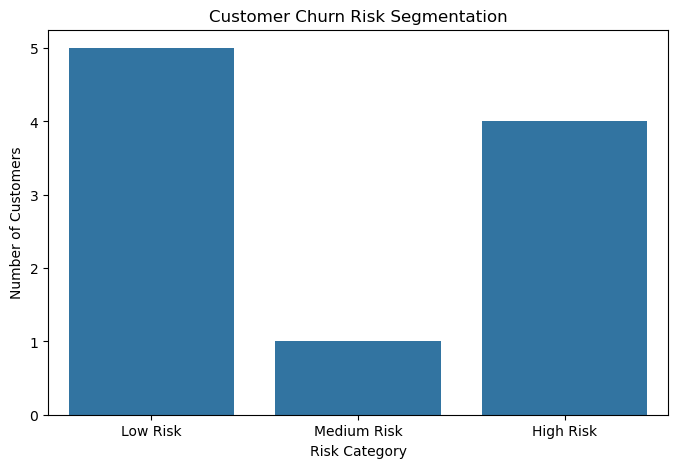

In [14]:
# Plot number of customers in each risk category

plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_risk,
    x="Risk_Level"
)

plt.title(
    "Customer Churn Risk Segmentation"
)

plt.xlabel(
    "Risk Category"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

## Interpretation

The customer segmentation process converts model predictions into actionable business categories.

Customers classified as **High Risk** have the greatest probability of leaving and should receive immediate retention interventions. These customers represent the highest priority because losing them may result in significant revenue loss.

Customers in the **Medium Risk** category may not require immediate intervention but should be monitored through personalized communication and engagement strategies.

Customers categorized as **Low Risk** demonstrate a lower likelihood of churn and should continue receiving standard customer engagement activities and loyalty programs.

This segmentation enables the business to allocate retention resources efficiently by focusing efforts where they are most likely to create value.

## Customer Risk Profile Analysis

While churn probabilities indicate the likelihood that a customer may leave, business teams need additional context to understand these customers and design appropriate retention strategies.

In this section, we combine the model predictions with important customer attributes such as contract type, tenure, and monthly charges.

This customer profile view provides a clearer understanding of which types of customers are at risk and helps the business develop targeted retention actions.
Combine Customer Information with Predictions

In [15]:
# Create customer profile table by combining original customer information with model predictions

customer_profile = new_customers.copy()


# Add customer identification

customer_profile["Customer_ID"] = range(
    1,
    len(customer_profile) + 1
)


# Add churn probability and prediction results

customer_profile["Churn_Probability"] = (
    prediction_results["Churn_Probability"]
)


customer_profile["Churn_Prediction"] = (
    prediction_results["Prediction_Label"]
)


# Add risk category

customer_profile["Risk_Level"] = (
    customer_risk["Risk_Level"]
)


# Display customer profile

customer_profile.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup,ContractMonths,TotalServices,Customer_ID,Churn_Probability,Churn_Prediction,Risk_Level
0,Female,0,Yes,Yes,72,Yes,No,Fiber optic,Yes,Yes,...,Bank transfer (automatic),29.85,2152.2,61-72 Months,24,5,1,0.012855,No Churn,Low Risk
1,Male,1,No,No,5,Yes,Yes,Fiber optic,No,No,...,Electronic check,95.50,477.5,0-12 Months,1,4,2,0.855289,Churn,High Risk
2,Female,0,Yes,No,24,Yes,No,DSL,Yes,Yes,...,Credit card (automatic),70.35,1688.4,13-24 Months,12,6,3,0.063778,No Churn,Low Risk
3,Male,0,No,No,2,No,No phone service,Fiber optic,No,No,...,Electronic check,99.40,198.8,0-12 Months,1,2,4,0.869832,Churn,High Risk
4,Female,1,No,Yes,48,Yes,Yes,DSL,Yes,No,...,Mailed check,65.25,3132.0,37-48 Months,12,6,5,0.048572,No Churn,Low Risk


In [16]:
# Select features that are most useful for business decisions

customer_risk_profile = customer_profile[
    [
        "Customer_ID",
        "Contract",
        "tenure",
        "MonthlyCharges",
        "InternetService",
        "PaymentMethod",
        "Churn_Probability",
        "Risk_Level"
    ]
].copy()


# Convert probability into percentage

customer_risk_profile[
    "Churn_Probability"
] = (
    customer_risk_profile[
        "Churn_Probability"
    ] * 100
).round(2)


# Rename column for clarity

customer_risk_profile = customer_risk_profile.rename(
    columns={
        "tenure": "Tenure_Months",
        "MonthlyCharges": "Monthly_Charges",
        "Churn_Probability": "Churn_Probability_%"
    }
)


# Display final customer risk profile

customer_risk_profile

,Customer_ID,Contract,Tenure_Months,Monthly_Charges,InternetService,PaymentMethod,Churn_Probability_%,Risk_Level
0,1,Two year,72,29.85,Fiber optic,Bank transfer (automatic),1.290000,Low Risk
1,2,Month-to-month,5,95.50,Fiber optic,Electronic check,85.529999,High Risk
2,3,One year,24,70.35,DSL,Credit card (automatic),6.380000,Low Risk
3,4,Month-to-month,2,99.40,Fiber optic,Electronic check,86.980003,High Risk
4,5,One year,48,65.25,DSL,Mailed check,4.860000,Low Risk
5,6,Two year,60,45.10,DSL,Bank transfer (automatic),1.720000,Low Risk
6,7,Month-to-month,12,89.75,Fiber optic,Electronic check,62.540001,Medium Risk
7,8,Month-to-month,8,101.20,Fiber optic,Electronic check,85.419998,High Risk
8,9,One year,36,60.50,DSL,Credit card (automatic),3.660000,Low Risk
9,10,Month-to-month,1,105.80,Fiber optic,Electronic check,89.879997,High Risk


### Interpretation

The customer risk profile combines machine learning predictions with customer characteristics to provide a business-friendly view of churn risk.

Customers with the highest churn probabilities tend to show patterns commonly associated with customer attrition, such as:

- Month-to-month contract agreements.
- Short customer tenure.
- Higher monthly charges.
- Limited commitment to long-term services.
- Payment methods associated with higher churn rates.

This information allows retention teams to move beyond prediction and understand the customer characteristics behind churn risk.

Instead of applying the same retention strategy to every customer, the business can design targeted interventions based on customer behavior and risk level.

# Recommended Business Actions

Predicting customer churn is only valuable when businesses can take appropriate action based on the prediction results.

In this section, customer risk categories are mapped to recommended retention strategies. The goal is to help the customer retention team understand what actions should be prioritized for each group.

By combining churn probability with customer risk segmentation, the business can allocate resources effectively and focus intervention efforts on customers with the highest potential value.

In [17]:
# Define recommended actions for each customer risk category

retention_strategy = {
    
    "High Risk": 
    "Immediate retention outreach, personalized offers, loyalty incentives, and proactive customer support.",
    
    "Medium Risk":
    "Monitor customer engagement, send personalized communication, and offer targeted promotions.",
    
    "Low Risk":
    "Maintain customer relationship through loyalty programs, regular engagement, and service improvements."
}


# Map strategies to customers

customer_risk_profile["Recommended_Action"] = (
    customer_risk_profile["Risk_Level"]
    .map(retention_strategy)
)


# Display customer recommendations

customer_risk_profile

,Customer_ID,Contract,Tenure_Months,Monthly_Charges,InternetService,PaymentMethod,Churn_Probability_%,Risk_Level,Recommended_Action
0,1,Two year,72,29.85,Fiber optic,Bank transfer (automatic),1.290000,Low Risk,Maintain customer relationship through loyalty...
1,2,Month-to-month,5,95.50,Fiber optic,Electronic check,85.529999,High Risk,"Immediate retention outreach, personalized off..."
2,3,One year,24,70.35,DSL,Credit card (automatic),6.380000,Low Risk,Maintain customer relationship through loyalty...
3,4,Month-to-month,2,99.40,Fiber optic,Electronic check,86.980003,High Risk,"Immediate retention outreach, personalized off..."
4,5,One year,48,65.25,DSL,Mailed check,4.860000,Low Risk,Maintain customer relationship through loyalty...
5,6,Two year,60,45.10,DSL,Bank transfer (automatic),1.720000,Low Risk,Maintain customer relationship through loyalty...
6,7,Month-to-month,12,89.75,Fiber optic,Electronic check,62.540001,Medium Risk,"Monitor customer engagement, send personalized..."
7,8,Month-to-month,8,101.20,Fiber optic,Electronic check,85.419998,High Risk,"Immediate retention outreach, personalized off..."
8,9,One year,36,60.50,DSL,Credit card (automatic),3.660000,Low Risk,Maintain customer relationship through loyalty...
9,10,Month-to-month,1,105.80,Fiber optic,Electronic check,89.879997,High Risk,"Immediate retention outreach, personalized off..."


## Interpretation

The retention strategy framework transforms churn predictions into practical business decisions.

### High Risk Customers

Customers in this category have the highest probability of leaving and should receive immediate attention. Recommended actions include personalized retention offers, direct customer engagement, and proactive support to understand and resolve potential dissatisfaction.

### Medium Risk Customers

These customers may not require urgent intervention but should be monitored closely. Personalized communication, service recommendations, and targeted promotions can help strengthen customer relationships before churn risk increases.

### Low Risk Customers

Low-risk customers demonstrate stronger retention characteristics. The focus should be on maintaining satisfaction through loyalty programs, continuous engagement, and high-quality service delivery.

This approach allows the organization to optimize retention resources by matching intervention intensity with customer risk level.

## Retention Priority Score

While churn probability identifies customers who are likely to leave, it does not consider the financial impact of losing each customer.

A high-value customer who is likely to churn represents a greater business risk than a low-value customer with the same churn probability.

To address this, a Retention Priority Score is created by combining:

- Customer churn risk.
- Monthly customer value.

This allows the business to prioritize retention efforts toward customers who represent the greatest potential revenue loss.

# Retention Priority Scoring

In [18]:
# Create a copy of customer risk profile

priority_df = customer_risk_profile.copy()


# Create numerical risk scores

risk_score_mapping = {
    "Low Risk": 1,
    "Medium Risk": 2,
    "High Risk": 3
}


priority_df["Risk_Score"] = (
    priority_df["Risk_Level"]
    .map(risk_score_mapping)
    .astype(int)
)

# Calculate retention priority score
# Higher score = higher priority for retention action

priority_df["Retention_Priority_Score"] = (
    priority_df["Risk_Score"] *
    priority_df["Monthly_Charges"]
)

# Sort customers by highest retention priority

priority_df = priority_df.sort_values(
    by="Retention_Priority_Score",
    ascending=False
)

# Display top priority customers

priority_df.head()

,Customer_ID,Contract,Tenure_Months,Monthly_Charges,InternetService,PaymentMethod,Churn_Probability_%,Risk_Level,Recommended_Action,Risk_Score,Retention_Priority_Score
9,10,Month-to-month,1,105.80,Fiber optic,Electronic check,89.879997,High Risk,"Immediate retention outreach, personalized off...",3,317.4
7,8,Month-to-month,8,101.20,Fiber optic,Electronic check,85.419998,High Risk,"Immediate retention outreach, personalized off...",3,303.6
3,4,Month-to-month,2,99.40,Fiber optic,Electronic check,86.980003,High Risk,"Immediate retention outreach, personalized off...",3,298.2
1,2,Month-to-month,5,95.50,Fiber optic,Electronic check,85.529999,High Risk,"Immediate retention outreach, personalized off...",3,286.5
6,7,Month-to-month,12,89.75,Fiber optic,Electronic check,62.540001,Medium Risk,"Monitor customer engagement, send personalized...",2,179.5


In [19]:
# Create business-friendly priority categories

def assign_priority(score):
    
    if score >= 200:
        return "Critical"
    
    elif score >= 100:
        return "High"
    
    else:
        return "Normal"



priority_df["Priority_Level"] = (
    priority_df["Retention_Priority_Score"]
    .apply(assign_priority)
)


# Display prioritized customers

priority_df[
    [
        "Customer_ID",
        "Risk_Level",
        "Monthly_Charges",
        "Retention_Priority_Score",
        "Priority_Level"
    ]
]

,Customer_ID,Risk_Level,Monthly_Charges,Retention_Priority_Score,Priority_Level
9,10,High Risk,105.80,317.40,Critical
7,8,High Risk,101.20,303.60,Critical
3,4,High Risk,99.40,298.20,Critical
1,2,High Risk,95.50,286.50,Critical
6,7,Medium Risk,89.75,179.50,High
2,3,Low Risk,70.35,70.35,Normal
4,5,Low Risk,65.25,65.25,Normal
8,9,Low Risk,60.50,60.50,Normal
5,6,Low Risk,45.10,45.10,Normal
0,1,Low Risk,29.85,29.85,Normal


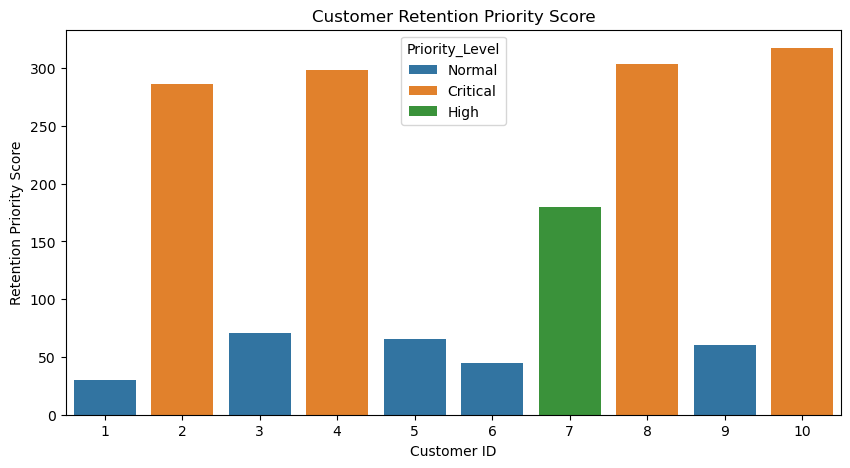

In [20]:
plt.figure(figsize=(10,5))


sns.barplot(
    data=priority_df,
    x="Customer_ID",
    y="Retention_Priority_Score",
    hue="Priority_Level"
)


plt.title(
    "Customer Retention Priority Score"
)

plt.xlabel(
    "Customer ID"
)

plt.ylabel(
    "Retention Priority Score"
)

plt.show()

# Feature Importance and Model Interpretation

Machine learning models can achieve high predictive performance, but understanding the reasons behind their predictions is equally important for business adoption.

In this section, we analyze the factors influencing customer churn predictions using model interpretation techniques.

Feature importance helps identify the characteristics that contribute most to churn predictions across all customers, while SHAP analysis provides a deeper explanation of individual customer predictions.

These insights allow the business to understand customer behavior patterns and develop more effective retention strategies.

## Global Feature Importance

XGBoost provides feature importance scores that measure how frequently and effectively each feature contributes to decision-making within the model.

The highest-ranked features represent customer characteristics that have the greatest influence on churn predictions.

In [21]:
# Extract XGBoost classifier from the pipeline

xgb_model = final_model.named_steps["classifier"]


# Get feature importance scores

importance_scores = xgb_model.feature_importances_


# Get transformed feature names from preprocessing pipeline

feature_names = preprocessor.get_feature_names_out()


# Create feature importance dataframe

feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance_scores

})


# Sort features by importance

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)


# Display top 20 important features

feature_importance_df.head(20)

,Feature,Importance
4,num__ContractMonths,0.330219
13,cat__InternetService_Fiber optic,0.172901
24,cat__TechSupport_No,0.055062
15,cat__OnlineSecurity_No,0.049196
14,cat__InternetService_No,0.031049
32,cat__StreamingMovies_Yes,0.026993
1,num__tenure,0.026735
39,cat__PaymentMethod_Electronic check,0.024399
12,cat__InternetService_DSL,0.023252
29,cat__StreamingTV_Yes,0.021193


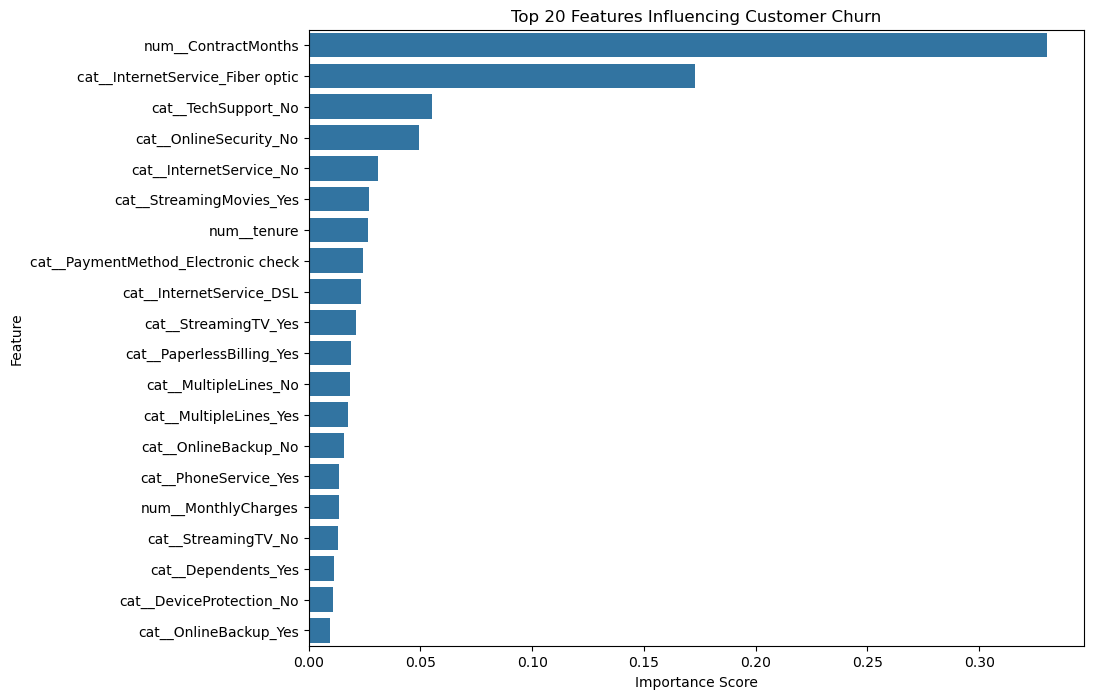

In [22]:
# Select top 20 features

top_features = (
    feature_importance_df
    .head(20)
)

# Plot feature importance

plt.figure(figsize=(10,8))


sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Features Influencing Customer Churn"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Feature"
)
plt.show()

## Interpretation

The feature importance analysis highlights the variables that have the strongest influence on churn prediction.

Features such as contract type, customer tenure, monthly charges, payment method, and additional services often play an important role in determining churn behavior.

For example:

- Customers with shorter tenure may have a higher likelihood of leaving because they have not yet developed strong loyalty.
- Month-to-month customers may be more likely to churn due to lower commitment compared with long-term contract customers.
- Higher monthly charges may increase churn risk if customers perceive insufficient value from the service.

These insights help the business understand customer behavior patterns and design targeted retention programs.

# SHAP Analysis

SHAP (SHapley Additive exPlanations) provides a detailed explanation of individual model predictions.

Unlike traditional feature importance, which only shows overall influence, SHAP explains:

- Which features increased churn probability.
- Which features reduced churn probability.
- Why a specific customer was classified as high or low risk.

This makes the model more transparent and easier for business stakeholders to trust.

In [23]:
# Create SHAP explainer for XGBoost model

explainer = shap.TreeExplainer(
    xgb_model
)


# Calculate SHAP values

shap_values = explainer.shap_values(
    new_customers_processed
)

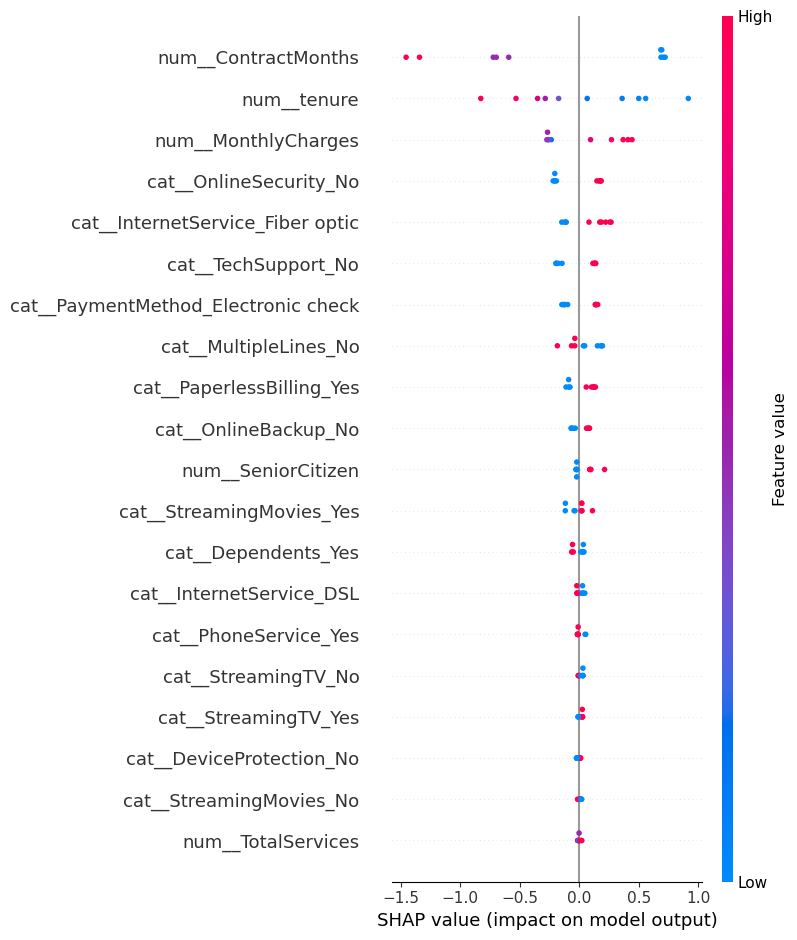

In [24]:
# Display global SHAP feature impact

shap.summary_plot(
    shap_values,
    new_customers_processed,
    feature_names=feature_names
)

In [25]:
# Select customer with highest churn probability

highest_risk_customer = (
    priority_df
    .iloc[0]
    ["Customer_ID"]
)


highest_risk_customer

np.int64(10)

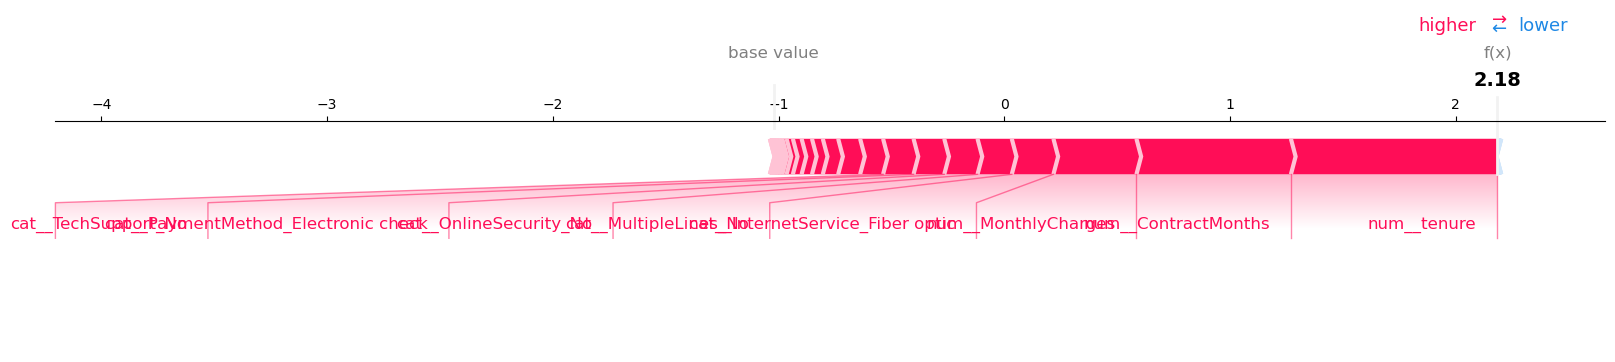

In [26]:
# Explain why this customer received a high-risk prediction

customer_index = int(highest_risk_customer) - 1


shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    feature_names=feature_names,
    matplotlib=True
)

## Interpretation

SHAP analysis provides transparency into individual churn predictions.

For high-risk customers, the model explanation can reveal the factors contributing to increased churn probability, such as:

- Short tenure.
- Month-to-month contracts.
- High monthly charges.
- Lack of support services.
- Certain payment methods.

This information enables personalized retention strategies. Instead of offering the same solution to every customer, the business can address the specific factors contributing to each customer's churn risk.

Model interpretability increases trust in machine learning systems and helps organizations make better customer retention decisions.

# Cost–Benefit Analysis

A successful machine learning solution should not only achieve good predictive performance but also create measurable business value.

In this section, we estimate the potential financial impact of using the churn prediction model to identify customers at risk of leaving.

The analysis compares the expected cost of retention activities against the potential revenue preserved by successfully retaining high-risk customers.

This provides a business perspective on the value of deploying the churn prediction system.

### Business Assumptions

To estimate the financial impact of the churn prediction system, several business assumptions are defined.

These values are hypothetical and can be replaced with real company data when available.

In [27]:
# Business assumptions

# Cost of running a retention campaign per customer
retention_cost_per_customer = 20


# Average monthly revenue generated by a customer
average_monthly_revenue = 75


# Expected months the customer would remain after successful retention
customer_lifetime_months = 12


# Estimated value of retaining one customer

customer_lifetime_value = (
    average_monthly_revenue *
    customer_lifetime_months
)


print(
    f"Estimated customer lifetime value: ${customer_lifetime_value}"
)

Estimated customer lifetime value: $900


### Identify High-Risk Customers

The first step is identifying customers who require immediate intervention.

High-risk customers are those with the greatest likelihood of churn and therefore represent the highest priority for retention campaigns.

In [28]:
# Select high-risk customers

high_risk_customers = (
    priority_df[
        priority_df["Risk_Level"] == "High Risk"
    ]
)

# Number of high-risk customers

number_high_risk = len(high_risk_customers)

print(
    f"Number of high-risk customers: {number_high_risk}"
)

Number of high-risk customers: 4


In [29]:
# Total cost of contacting high-risk customers

total_retention_cost = (
    number_high_risk *
    retention_cost_per_customer
)


print(
    f"Total retention campaign cost: ${total_retention_cost}"
)

Total retention campaign cost: $80


## Estimate Potential Revenue Saved

The potential value of the churn model comes from preventing customer loss.

This calculation assumes that successfully retaining a high-risk customer preserves their expected customer lifetime value.

In [30]:
# Assume 50% of targeted customers can be successfully retained

retention_success_rate = 0.50


# Estimate number of customers saved

customers_saved = (
    number_high_risk *
    retention_success_rate
)


# Estimate revenue preserved

estimated_revenue_saved = (
    customers_saved *
    customer_lifetime_value
)


print(
    f"Estimated customers retained: {customers_saved}"
)


print(
    f"Estimated revenue saved: ${estimated_revenue_saved}"
)

Estimated customers retained: 2.0
Estimated revenue saved: $1800.0


## Return on Investment (ROI)

ROI measures whether the financial benefit of using the churn model exceeds the cost of running retention activities.

A positive ROI indicates that the retention strategy generates more value than it costs.

In [31]:
# Calculate ROI

roi = (
    (estimated_revenue_saved - total_retention_cost)
    /
    total_retention_cost
) * 100


print(
    f"Estimated ROI: {roi:.2f}%"
)

Estimated ROI: 2150.00%


In [32]:
# Business impact summary

business_impact = pd.DataFrame({

    "Metric": [
        "High-Risk Customers Identified",
        "Retention Campaign Cost",
        "Customers Successfully Retained",
        "Estimated Revenue Saved",
        "ROI (%)"
    ],

    "Value": [
        number_high_risk,
        f"${total_retention_cost}",
        customers_saved,
        f"${estimated_revenue_saved}",
        f"{roi:.2f}%"
    ]
})


business_impact

,Metric,Value
0,High-Risk Customers Identified,4
1,Retention Campaign Cost,$80
2,Customers Successfully Retained,2.0
3,Estimated Revenue Saved,$1800.0
4,ROI (%),2150.00%


## Interpretation

The cost-benefit analysis demonstrates the potential financial value of implementing the churn prediction system.

By identifying high-risk customers before they leave, the business can focus retention resources on customers who represent the greatest potential revenue loss.

Although the analysis uses hypothetical assumptions, the framework demonstrates how predictive analytics can support measurable business outcomes.

In a real deployment, the assumptions can be replaced with actual customer lifetime value, retention campaign costs, and historical retention success rates to calculate the true financial impact.